In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
promotions_csv = pd.read_csv('/content/q3_retail_promotions.csv')

# **Task 1. Date Feature Engineering**

In [27]:
from numpy._core.numeric import astype
# Covert to datetime
promotions_csv['transaction_date'] = pd.to_datetime(promotions_csv['transaction_date'])

# Extract Features
promotions_csv['year'] = promotions_csv['transaction_date'].dt.year
promotions_csv['month'] = promotions_csv['transaction_date'].dt.month
promotions_csv['day_of_week'] = promotions_csv['transaction_date'].dt.dayofweek

# Create is_month_end feature
promotions_csv['is_month_end'] = (promotions_csv['transaction_date'].dt.day >= 25).astype(int)

# Check sample
promotions_csv.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


# **Task 2. Temporal Train-Test Split**

In [28]:
from re import split
# Sort by transaction_date
promotions_csv = promotions_csv.sort_values(by='transaction_date')

# Split 80% training and 20% test data
split_index = int(0.8 * len(promotions_csv))

train= promotions_csv.iloc[:split_index]
test = promotions_csv.iloc[split_index:]

promotions_csv.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


# **Markdown**
Random train-test split is not right for time-ordered data because it break orginal sequence.

For temporal train-test I used first 80% of the old data for training for future and 20% of the data for test current set.

By keeping this order:



*   The model is trained only on historical data
*   The test will help future predictions.



# **Task 3. Preprocessing Pipeline**



In [29]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [30]:
# Define Columns
categories_cols = ['store_size', 'location_type', 'promotion_type']
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude 'items_sold' from numerical_cols if it is the target variable
if 'items_sold' in numerical_cols:
    numerical_cols.remove('items_sold')

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categories_cols)
    ]
)

# Pipeline Model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Features and targets:
X_train = train.drop(columns=['items_sold'])
y_train = train['items_sold']
X_test = test.drop(columns=['items_sold'])
y_test = test['items_sold']

# Fit the model
pipeline.fit(X_train, y_train)

# Prediction
y_pred = pipeline.predict(X_test)

# **Task 4. Model Training and Evaluation**


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [32]:
# Linear Regression model and Random Forest Regressor inside Pipeline
pipe_linear = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
pipe_random_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Fit
pipe_linear.fit(X_train, y_train)
pipe_random_forest.fit(X_train, y_train)

# Prediction
y_pred_linear = pipe_linear.predict(X_test)
y_pred_random_forest = pipe_random_forest.predict(X_test)

# Evaluate
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
rmse_random_forest = np.sqrt(mean_squared_error(y_test, y_pred_random_forest))

mae_linear = mean_squared_error(y_test, y_pred_linear)
mae_random_forest = mean_squared_error(y_test, y_pred_random_forest)

# Print
print("Linear Regression RMSE: ", rmse_linear, "Linear Regression MAE: ", mae_linear)
print("Random Forest RMSE: ", rmse_random_forest, "Random Forest MAE: ", mae_random_forest)


Linear Regression RMSE:  27.112589498018185 Linear Regression MAE:  735.0925092880459
Random Forest RMSE:  30.784274611026618 Random Forest MAE:  947.671563327098


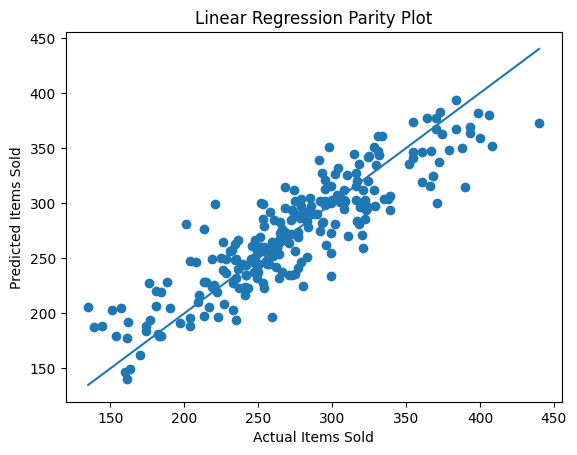

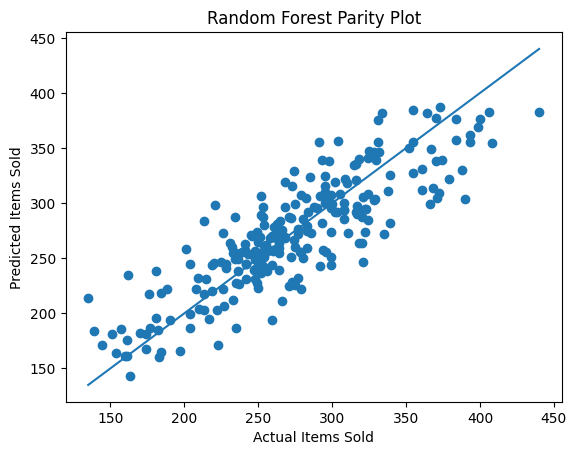

In [33]:
# Parity Plots

# Linear Regression
plt.figure()
plt.scatter(y_test, y_pred_linear)
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)])
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Linear Regression Parity Plot')
plt.show()

# Random Forest
plt.figure()
plt.scatter(y_test, y_pred_random_forest)
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)])
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Random Forest Parity Plot')
plt.show()

In [34]:
# Feature importances from the Random Forest
ohe_feature_names = pipe_random_forest.named_steps['preprocessor'].named_transformers_['cat']
cat_features = ohe_feature_names.get_feature_names_out(categories_cols)

# Combine numerical and categorical feature names
features_name = numerical_cols + list(cat_features)

# Importances
importances = pipe_random_forest.named_steps['model'].feature_importances_

# Top 5 features
feature_importances = pd.Series(importances, index=features_name).sort_values(ascending=False)

print("Top 5 features: ")
print(feature_importances.head(5))

Top 5 features: 
is_festival            0.173801
store_size_small       0.165731
is_weekend             0.128520
location_type_urban    0.109868
store_id               0.089041
dtype: float64
